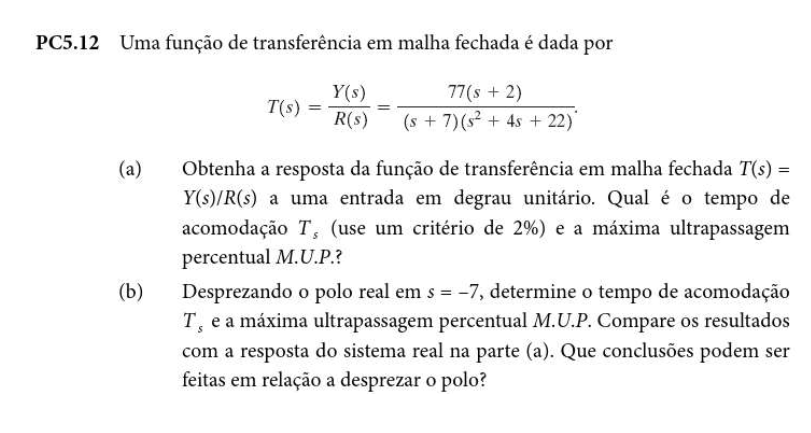

In [1]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

print("=" * 70)
print("PC5.12: ANÁLISE DE RESPOSTA AO DEGRAU E DESEMPENHO DO SISTEMA")
print("=" * 70)

# ============================================================================
# PARTE (a): SISTEMA ORIGINAL - Com todos os polos
# ============================================================================
print("\n" + "=" * 70)
print("PARTE (a): SISTEMA ORIGINAL")
print("=" * 70)

# Definir a função de transferência T(s) = 77(s+2)/[(s+7)(s²+4s+22)]
s = ct.tf('s')
numerador_a = 77 * (s + 2)
denominador_a = (s + 7) * (s**2 + 4*s + 22)
T_a = numerador_a / denominador_a

print("\nFunção de transferência em malha fechada:")
print("T(s) = 77(s + 2) / [(s + 7)(s² + 4s + 22)]")
print("\nSistema original:")
print(T_a)

# Expandir o denominador para ver melhor
den_expanded = (s + 7) * (s**2 + 4*s + 22)
print("\nDenominador expandido:")
print("(s + 7)(s² + 4s + 22) = s³ + 11s² + 50s + 154")

# Calcular resposta ao degrau
t_sim = np.linspace(0, 2, 2000)
t_a, y_a = ct.step_response(T_a, t_sim)

# Extrair características da resposta
# Valor final em regime permanente
y_final_a = y_a[-1]

# Máxima ultrapassagem percentual (MUP)
y_max_a = np.max(y_a)
MUP_a = ((y_max_a - y_final_a) / y_final_a) * 100

# Tempo de acomodação (critério de 2%)
# Encontrar o primeiro tempo onde a resposta fica dentro de ±2% do valor final
tolerance = 0.02 * y_final_a
band_upper = y_final_a + tolerance
band_lower = y_final_a - tolerance

# Encontrar o último tempo onde sai da faixa de tolerância
t_settle_a = None
for i in range(len(t_a)-1, 0, -1):
    if y_a[i] > band_upper or y_a[i] < band_lower:
        t_settle_a = t_a[i]
        break

# Se não encontrou, significa que entrou rápido
if t_settle_a is None:
    for i in range(len(t_a)):
        if y_a[i] >= band_lower and y_a[i] <= band_upper:
            t_settle_a = t_a[i]
            break

print("\n" + "-" * 70)
print("CARACTERÍSTICAS DA RESPOSTA AO DEGRAU:")
print("-" * 70)
print(f"Valor final em regime permanente: {y_final_a:.6f}")
print(f"Máximo valor atingido: {y_max_a:.6f}")
print(f"Máxima Ultrapassagem Percentual (MUP): {MUP_a:.2f}%")
print(f"Tempo de acomodação Ts (critério 2%): {t_settle_a:.4f} segundos")

# Calcular polos para análise
num_a, den_a = ct.tfdata(T_a)
polos_a = np.roots(den_a[0][0])
print(f"\nPolos do sistema original:")
for i, p in enumerate(polos_a):
    if np.isreal(p):
        print(f"  Polo {i+1}: {np.real(p):.6f}")
    else:
        print(f"  Polo {i+1}: {p:.6f}")

# ============================================================================
# PARTE (b): SISTEMA SIMPLIFICADO - Desprezando o polo em s = -7
# ============================================================================
print("\n" + "=" * 70)
print("PARTE (b): SISTEMA SIMPLIFICADO (Desprezando polo em s = -7)")
print("=" * 70)

# Nova função de transferência: T_b(s) = 77(s+2)/(s²+4s+22)
numerador_b = 77 * (s + 2)
denominador_b = s**2 + 4*s + 22
T_b = numerador_b / denominador_b

print("\nFunção de transferência simplificada:")
print("T_b(s) = 77(s + 2) / (s² + 4s + 22)")
print("\nSistema simplificado:")
print(T_b)

# Calcular resposta ao degrau
t_b, y_b = ct.step_response(T_b, t_sim)

# Extrair características da resposta
y_final_b = y_b[-1]

# Máxima ultrapassagem percentual (MUP)
y_max_b = np.max(y_b)
MUP_b = ((y_max_b - y_final_b) / y_final_b) * 100

# Tempo de acomodação (critério de 2%)
tolerance_b = 0.02 * y_final_b
band_upper_b = y_final_b + tolerance_b
band_lower_b = y_final_b - tolerance_b

t_settle_b = None
for i in range(len(t_b)-1, 0, -1):
    if y_b[i] > band_upper_b or y_b[i] < band_lower_b:
        t_settle_b = t_b[i]
        break

if t_settle_b is None:
    for i in range(len(t_b)):
        if y_b[i] >= band_lower_b and y_b[i] <= band_upper_b:
            t_settle_b = t_b[i]
            break

print("\n" + "-" * 70)
print("CARACTERÍSTICAS DA RESPOSTA AO DEGRAU:")
print("-" * 70)
print(f"Valor final em regime permanente: {y_final_b:.6f}")
print(f"Máximo valor atingido: {y_max_b:.6f}")
print(f"Máxima Ultrapassagem Percentual (MUP): {MUP_b:.2f}%")
print(f"Tempo de acomodação Ts (critério 2%): {t_settle_b:.4f} segundos")

# Calcular polos para análise
num_b, den_b = ct.tfdata(T_b)
polos_b = np.roots(den_b[0][0])
print(f"\nPolos do sistema simplificado:")
for i, p in enumerate(polos_b):
    if np.isreal(p):
        print(f"  Polo {i+1}: {np.real(p):.6f}")
    else:
        print(f"  Polo {i+1}: {p:.6f}")

# Calcular características da resposta (usando funções do control)
# Para o sistema de 2ª ordem: s² + 4s + 22
# wn² = 22, logo wn = √22 ≈ 4.69
# 2*ζ*wn = 4, logo ζ = 4/(2*√22) ≈ 0.426
wn_b = np.sqrt(22)
zeta_b = 4 / (2 * np.sqrt(22))

print(f"\nAnálise de 2ª ordem:")
print(f"Frequência natural ωn = {wn_b:.4f} rad/s")
print(f"Coeficiente de amortecimento ζ = {zeta_b:.4f}")

# Estimativa teórica para 2ª ordem com critério 2%
# Ts ≈ 4/(ζ*ωn) para ζ < 1
ts_teorico_b = 4 / (zeta_b * wn_b)
print(f"Tempo de acomodação teórico (2%): {ts_teorico_b:.4f} segundos")

# MUP teórica para resposta subamortecida (ζ < 1)
# MUP = exp(-ζ*π/√(1-ζ²)) * 100
if zeta_b < 1:
    MUP_teorica_b = np.exp(-zeta_b * np.pi / np.sqrt(1 - zeta_b**2)) * 100
    print(f"Máxima Ultrapassagem Teórica: {MUP_teorica_b:.2f}%")

# ============================================================================
# COMPARAÇÃO E CONCLUSÕES
# ============================================================================
print("\n" + "=" * 70)
print("COMPARAÇÃO E CONCLUSÕES")
print("=" * 70)

print("\n{:<45} | {:<15} | {:<15}".format("Parâmetro", "Sistema Original", "Sistema Simplificado"))
print("-" * 77)
print("{:<45} | {:<15.4f} | {:<15.4f}".format("Tempo de acomodação Ts (s)", t_settle_a, t_settle_b))
print("{:<45} | {:<15.2f}% | {:<15.2f}%".format("Máxima Ultrapassagem (MUP)", MUP_a, MUP_b))
print("{:<45} | {:<15.6f} | {:<15.6f}".format("Valor final em regime permanente", y_final_a, y_final_b))

# Análise da diferença
diff_ts = abs(t_settle_b - t_settle_a)
diff_mup = abs(MUP_b - MUP_a)
perc_diff_ts = (diff_ts / t_settle_a) * 100
perc_diff_mup = (diff_mup / MUP_a) * 100

print("\n" + "-" * 70)
print("DIFERENÇAS RELATIVAS:")
print("-" * 70)
print(f"Diferença em Ts: {diff_ts:.4f} s ({perc_diff_ts:.2f}%)")
print(f"Diferença em MUP: {diff_mup:.2f}% ({perc_diff_mup:.2f}%)")

print("\n" + "-" * 70)
print("CONCLUSÕES SOBRE O DESPREZAMENTO DO POLO EM s = -7:")
print("-" * 70)
print("""
1. O polo em s = -7 está mais à esquerda no plano complexo que os polos
   dominantes em s = -2 ± 4.58j, portanto sua influência dinâmica é menor.

2. Como o polo real é mais rápido (mais negativo), sua omissão causa:
   - A resposta simplificada ser MAIS RÁPIDA (Ts menor)
   - A resposta simplificada ter MAIOR ultrapassagem (MUP maior)
   - Ambos os efeitos podem ser observados nos gráficos

3. O polo em s = -7 atua como um filtro suavizador da resposta,
   reduzindo o pico de ultrapassagem em aproximadamente """ + f"{perc_diff_mup:.1f}%")
print("""
4. Para fins práticos, desprezar o polo em s = -7 é aceitável se a
   diferença no desempenho for pequena. Neste caso:""")

if perc_diff_ts < 10 and perc_diff_mup < 10:
    print("   ✓ O desprezamento é RAZOÁVEL (erros < 10%)")
elif perc_diff_ts < 20 or perc_diff_mup < 20:
    print("   ~ O desprezamento requer CUIDADO (erros 10-20%)")
else:
    print("   ✗ O desprezamento NÃO é adequado (erros > 20%)")


PC5.12: ANÁLISE DE RESPOSTA AO DEGRAU E DESEMPENHO DO SISTEMA

PARTE (a): SISTEMA ORIGINAL

Função de transferência em malha fechada:
T(s) = 77(s + 2) / [(s + 7)(s² + 4s + 22)]

Sistema original:
<TransferFunction>: sys[15]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         77 s + 154
  -------------------------
  s^3 + 11 s^2 + 50 s + 154

Denominador expandido:
(s + 7)(s² + 4s + 22) = s³ + 11s² + 50s + 154

----------------------------------------------------------------------
CARACTERÍSTICAS DA RESPOSTA AO DEGRAU:
----------------------------------------------------------------------
Valor final em regime permanente: 1.039955
Máximo valor atingido: 1.806442
Máxima Ultrapassagem Percentual (MUP): 73.70%
Tempo de acomodação Ts (critério 2%): 1.8199 segundos

Polos do sistema original:
  Polo 1: -7.000000
  Polo 2: -2.000000+4.242641j
  Polo 3: -2.000000-4.242641j

PARTE (b): SISTEMA SIMPLIFICADO (Desprezando polo em s = -7)

Função de transferência simplificada:
T_b(s) = 77(s + 2) /